<a href="https://colab.research.google.com/github/AMJAMAITHILI/DL_LAB/blob/main/WEEK10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Guided Backpropagation**

Guided Backpropagation is a visualization technique used to understand which input pixels most strongly influence the output of a neural network. It modifies standard backpropagation so that only positive gradients are allowed to flow backward through ReLU activations.

Core Idea:
Only features that positively contribute to neuron activation are propagated backward, producing a clearer and more interpretable saliency map.

Working Principle (Step-by-Step)

Forward pass the input image through the network.
Select a target neuron (e.g., output class score).
Compute gradients of the output with respect to the input.
Modify backpropagation rule at ReLU:
Allow gradients only if:
Forward activation > 0
Backward gradient > 0
Propagate modified gradients back to input.
The resulting gradient map highlights important pixels.

Mathematical Condition (Guided ReLU)

Gradient passes only if:

Forward activation > 0 AND Gradient > 0

Otherwise gradient = 0

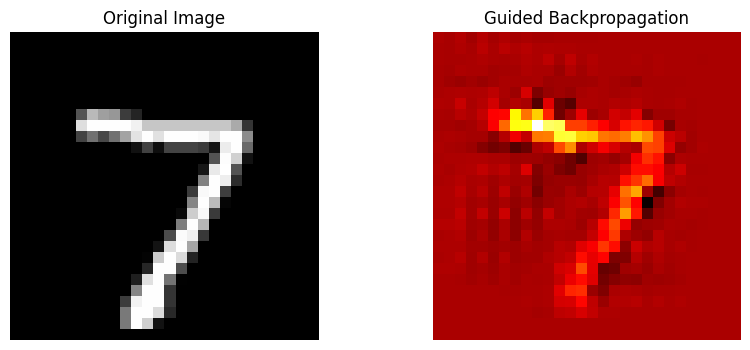

In [5]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist

# 1. Load MNIST
(x_train, y_train), (x_test, y_test) = mnist.load_data()

x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

# 2. Build simple CNN (perceptron-like classifier)
model = models.Sequential([
    layers.Conv2D(16, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D(),
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.fit(x_train, y_train, epochs=3, batch_size=128, verbose=0)

# 3. Define Guided ReLU
@tf.custom_gradient
def guided_relu(x):
    def grad(dy):
        return tf.cast(dy > 0, tf.float32) * tf.cast(x > 0, tf.float32) * dy
    return tf.nn.relu(x), grad

# Replace all ReLU activations
for layer in model.layers:
    if hasattr(layer, 'activation') and layer.activation == tf.keras.activations.relu:
        layer.activation = guided_relu

# 4. Select one test image
label = y_test[0]
img = tf.convert_to_tensor(x_test[0:1])  # FIX
#compute guided gradients
with tf.GradientTape() as tape:
    tape.watch(img)
    preds = model(img)
    loss = preds[:, label]

grads = tape.gradient(loss, img)

# 6. Process gradients
grads = grads.numpy()[0]
grads = (grads - grads.min()) / (grads.max() - grads.min())

# 7. Visualize
plt.figure(figsize=(10,4))

# Original
plt.subplot(1,2,1)
plt.imshow(img.numpy()[0].reshape(28,28), cmap='gray')
plt.title("Original Image")
plt.axis('off')

# Guided Backprop
plt.subplot(1,2,2)
plt.imshow(grads.reshape(28,28), cmap='hot')
plt.title("Guided Backpropagation")
plt.axis('off')

plt.show()


**Bright (yellow/red) pixels → highly important**

Dark pixels → not important
**bold text**

->Edges of the digit are highlighted
->Stroke regions are bright
->Background is mostly black

The model focuses on:

* Digit boundaries
* Stroke thickness
* Shape features

It ignores:

* Background noise
* Empty pixels